In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ── Step 1: Your factor matrix ────────────────────────────────
# Assume df is your cleaned, forward-filled, differenced dataframe
# Columns: Gold, Crude, USDINR, VIX, FII, DII, Bonds, US10Y,
#          TradeDeficit, GDP, CPI, RepoRate, Nifty, SectorIdx, Volume
#          + ICICI_close as target

factor_cols = [
    'Gold', 'Crude', 'USDINR', 'VIX',
    'FII', 'DII', 'IndBonds', 'US10Y',
    'd_TradeDeficit', 'd_GDP', 'd_CPI', 'd_RepoRate',
    'Nifty', 'SectorIdx', 'Volume'
]

X = df[factor_cols].values          # shape: (n_days, 14)
y = df['ICICI_close'].values        # shape: (n_days,)

# ── Step 2: Standardise — mandatory before projection ─────────
# Each factor is on a different scale (Gold in ₹, VIX in %, etc.)
# Without this, Gold swamps everything just because it's large numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # now every column: mean=0, std=1

# ── Step 3: Project ICICI price onto the factor space ─────────
# This fits: Price = β₀ + β₁F₁ + β₂F₂ + ... + β₁₄F₁₄
reg = LinearRegression()
reg.fit(X_scaled, y)

price_projected = reg.predict(X_scaled)  # the linear combination

# ── Step 4: The residual — this is the KEY output ─────────────
residual = y - price_projected

# Residual = what the factors CANNOT explain
# If residual > 0  → price is above what factors justify  → overpriced
# If residual < 0  → price is below what factors justify  → underpriced

# ── Step 5: See how much each factor contributes ──────────────
loadings = pd.Series(reg.coef_, index=factor_cols).sort_values()
print("Factor loadings (standardised):")
print(loadings)
# Positive loading = factor going up → price goes up
# Negative loading = factor going up → price goes down

# ── Step 6: Check how well the factors explain price ──────────
r2 = reg.score(X_scaled, y)
print(f"\nR² = {r2:.3f}")
# R² = 0.7 means 70% of price movement explained by your 14 factors
# Residual holds the remaining 30% — that's your mean-reversion target

# ── Step 7: Plot actual vs projected ──────────────────────────
plt.figure(figsize=(14, 5))
plt.subplot(2, 1, 1)
plt.plot(df.index, y, label='Actual ICICI', alpha=0.8)
plt.plot(df.index, price_projected, label='Factor projection', alpha=0.8)
plt.legend()
plt.title('Actual vs factor-projected price')

plt.subplot(2, 1, 2)
plt.plot(df.index, residual, color='red', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Residual (what OU will model)')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [5]:
import statsmodels
dir(statsmodels)


['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '__version_info__',
 '__version_tuple__',
 '_version',
 'compat',
 'debug_warnings',
 'monkey_patch_cat_dtype',
 'test',
 'tools']

In [4]:
help(statsmodels)

Help on package statsmodels:

NAME
    statsmodels

PACKAGE CONTENTS
    _version
    api
    base (package)
    compat (package)
    conftest
    datasets (package)
    discrete (package)
    distributions (package)
    duration (package)
    emplike (package)
    formula (package)
    gam (package)
    genmod (package)
    graphics (package)
    imputation (package)
    interface (package)
    iolib (package)
    miscmodels (package)
    multivariate (package)
    nonparametric (package)
    othermod (package)
    regression (package)
    robust (package)
    sandbox (package)
    src (package)
    stats (package)
    tests (package)
    tools (package)
    treatment (package)
    tsa (package)

FUNCTIONS
    test(extra_args=None, exit=False)
        Run the test suite
        
        Parameters
        ----------
        extra_args : list[str]
            List of argument to pass to pytest when running the test suite. The
            default is ['--tb=short', '--disable-pytest-warn

In [6]:



def load (filename,path, **kwargs):
    df = os.path.join(data-dir,filename)
    pd.read_csv(path,**kwargs)
    if 'date' in df.columns:
        df[date_col]=pd.to_datetime(df[date_col ])
        df=df.set_index(date_col).sort_index()
    return df


In [1]:
import pandas as pd
cd = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/ICICI_Bank_Quarterly_Results_FY2010_FY2026 copy.csv")
cd.head()

,Fiscal Year,Quarter,Period,NII (₹ Cr),NII QoQ Change (₹ Cr),NII YoY Change (₹ Cr),Net Profit (₹ Cr),PAT QoQ Change (₹ Cr),PAT YoY Change (₹ Cr),Data Source
0,FY2010,Q1,Apr–Jun 2009,2100,NaN,NaN,878,NaN,NaN,Estimated
1,FY2010,Q2,Jul–Sep 2009,2079,-21.0,NaN,1038,160.0,NaN,Estimated
2,FY2010,Q3,Oct–Dec 2009,2058,-21.0,NaN,1101,63.0,NaN,NII Confirmed; PAT Derived
3,FY2010,Q4,Jan–Mar 2010,2035,-23.0,NaN,1008,-93.0,NaN,Both Confirmed
4,FY2011,Q1,Apr–Jun 2010,2261,226.0,161.0,1026,18.0,148.0,Estimated


In [ ]:
import pandas as pd
A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A['date']=pd.to_datetime(A['date'])
B['date']=pd.to_datetime(B['date'])

B_monthly=B.set_index('date')[['close']].resample('ME').last().reset_index()

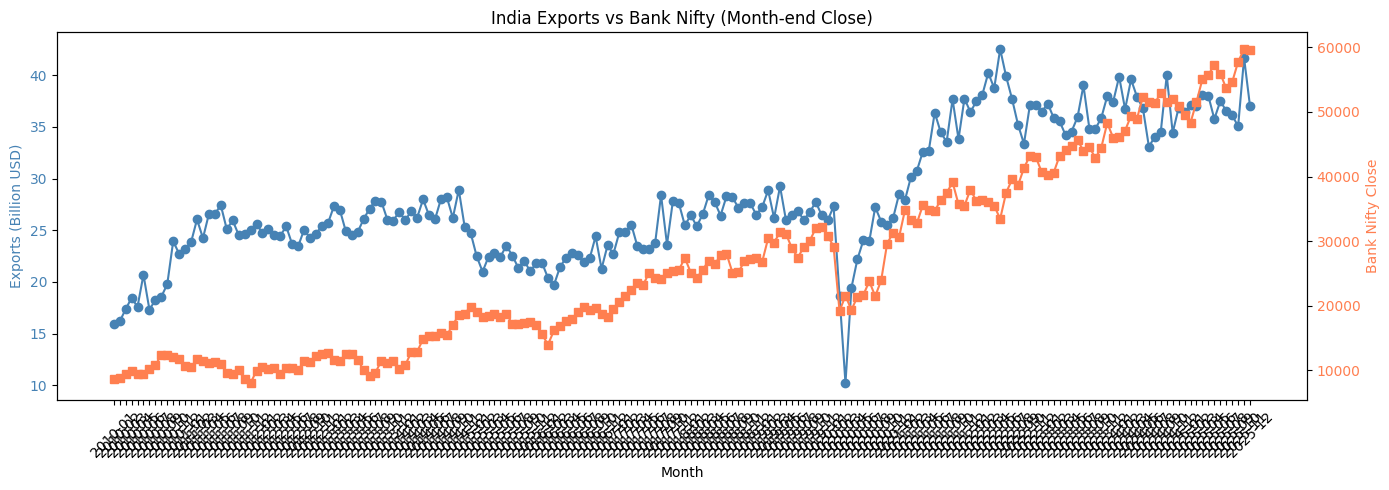

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

# Parse dates
A["date"] = pd.to_datetime(A["Date"])   # change "date" to your actual date column name
B["date"] = pd.to_datetime(B["Date"])

# Resample Nifty to month-end Close
B_monthly = B.set_index("date")["Close"].resample("ME").last().reset_index()

# Merge on month
A["month"] = A["date"].dt.to_period("M")
B_monthly["month"] = B_monthly["date"].dt.to_period("M")

merged = pd.merge(A[["month", "Exports_Billion_USD"]], B_monthly[["month", "Close"]], on="month")

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Month")
ax1.set_ylabel("Exports (Billion USD)", color="steelblue")
ax1.plot(merged["month"].astype(str), merged["Exports_Billion_USD"], color="steelblue", marker="o", label="Exports")
ax1.tick_params(axis="y", labelcolor="steelblue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()  # second Y-axis
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.plot(merged["month"].astype(str), merged["Close"], color="coral", marker="s", label="Bank Nifty Close")
ax2.tick_params(axis="y", labelcolor="coral")

plt.title("India Exports vs Bank Nifty (Month-end Close)")
fig.tight_layout()
plt.show()

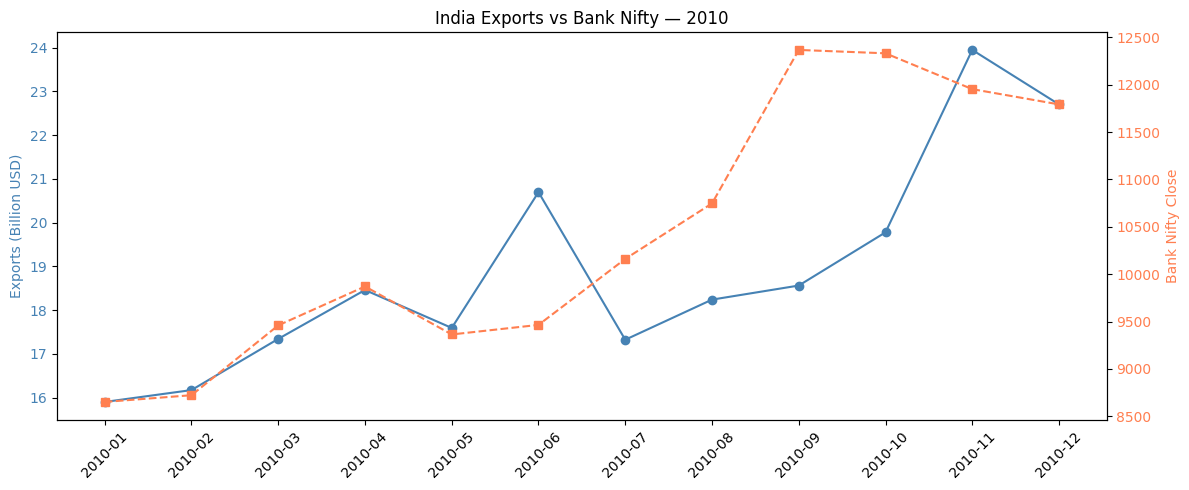

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A["Date"] = pd.to_datetime(A["Date"])
B["Date"] = pd.to_datetime(B["Date"])

# Filter 2010
A = A[A["Date"].dt.year == 2010]
B = B[B["Date"].dt.year == 2010]

# Resample Nifty to month-end
B_monthly = B.set_index("Date")["Close"].resample("ME").last().reset_index()

# Merge
A["month"] = A["Date"].dt.to_period("M")
B_monthly["month"] = B_monthly["Date"].dt.to_period("M")
merged = pd.merge(A[["month","Exports_Billion_USD"]], B_monthly[["month","Close"]], on="month")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(merged["month"].astype(str), merged["Exports_Billion_USD"], color="steelblue", marker="o")
ax1.set_ylabel("Exports (Billion USD)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(merged["month"].astype(str), merged["Close"], color="coral", marker="s", linestyle="--")
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

plt.title("India Exports vs Bank Nifty — 2010")
fig.tight_layout()
plt.show()

In [5]:
print(B[B["Date"].dt.year == 2010].columns.tolist())
print(B[B["Date"].dt.year == 2010].head(12).to_string())

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14']
         Date         Open         High          Low        Close  Volume     RSI_14
0  2010-01-21  9092.894468  9097.994019  8888.946640  8919.196289       0  36.720769
1  2010-01-22  8891.696863  8891.696863  8659.800133  8772.548828       0  29.486735
2  2010-01-25  8724.697913  8751.097995  8669.448558  8696.498047       0  26.564081
3  2010-01-27  8564.500204  8602.550544  8294.503338  8329.703125       0  17.536135
4  2010-01-28  8396.402661  8496.001116  8354.153151  8423.751953       0  24.610981
5  2010-01-29  8346.452765  8686.899002  8306.003040  8651.449219       0  38.391953
6  2010-02-01  8597.350212  8712.148681  8495.151205  8649.149414       0  38.315768
7  2010-02-02  8666.599250  8718.548840  8453.801924  8468.051758       0  32.796724
8  2010-02-03  8489.700874  8662.849247  8489.700874  8631.749023       0  41.060960
9  2010-02-04  8591.699767  8623.149596  8455.401549  8471.000977       0  36.335613
10 2

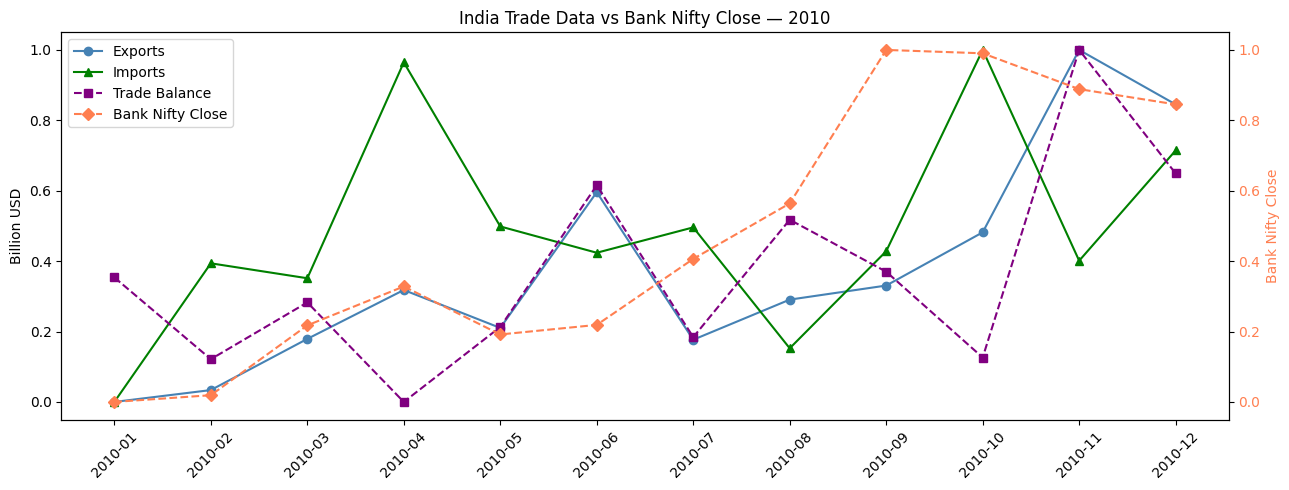

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A["Date"] = pd.to_datetime(A["Date"])
B["Date"] = pd.to_datetime(B["Date"])

A = A[A["Date"].dt.year == 2010]
B = B[B["Date"].dt.year == 2010]

B_monthly = B.set_index("Date")["Close"].resample("ME").last().reset_index()

A["month"] = A["Date"].dt.to_period("M")
B_monthly["month"] = B_monthly["Date"].dt.to_period("M")
merged = pd.merge(A[["month","Exports_Billion_USD","Imports_Billion_USD","Trade_Balance_Billion_USD"]], B_monthly[["month","Close"]], on="month")


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ["Exports_Billion_USD", "Imports_Billion_USD", "Trade_Balance_Billion_USD", "Close"]
merged[cols] = scaler.fit_transform(merged[cols])


fig, ax1 = plt.subplots(figsize=(13, 5))

months = merged["month"].astype(str)
ax1.plot(months, merged["Exports_Billion_USD"], color="steelblue", marker="o", label="Exports")
ax1.plot(months, merged["Imports_Billion_USD"], color="green", marker="^", label="Imports")
ax1.plot(months, merged["Trade_Balance_Billion_USD"], color="purple", marker="s", linestyle="--", label="Trade Balance")
ax1.set_ylabel("Billion USD")
ax1.tick_params(axis="y")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(months, merged["Close"], color="coral", marker="D", linestyle="--", label="Bank Nifty Close")
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")



plt.title("India Trade Data vs Bank Nifty Close — 2010")
fig.tight_layout()
plt.show()

In [1]:
pip install nsepython

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
from nseutils_bhav.api import get_live_quote

# 1. Fetch data safely
data = get_live_quote("ICICIBANK")

# 2. Extract the price (using the updated key structure)
try:
    live_price = data["data"][0]["lastPrice"]
    print(f"ICICI Bank Live Price: ₹{live_price}")
except (KeyError, IndexIndexError):
    # Fallback if keys shift again
    print("Structure changed. Dumped keys available:", data.keys())

ModuleNotFoundError: No module named 'nseutils_bhav'

In [3]:
icici_data.head()

AttributeError: 'dict' object has no attribute 'head'

In [1]:
pip install nseutils-bhav


ERROR: Could not find a version that satisfies the requirement nseutils-bhav (from versions: none)
ERROR: No matching distribution found for nseutils-bhav

[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
